# **OBJECTIVE**

## *The goal of this project is to estimate instructor effectiveness using machine learning by analyzing student performace ,feedback and engagement.*

# **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# **Loading Data**

In [2]:
df=pd.read_csv("/content/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

# **Data Understaning**

In [3]:
df.head(3)

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.30000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.65722,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.30000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433


In [4]:
df.shape

(2000, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [6]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


# **Exploratory Data Analysis (EDA)**

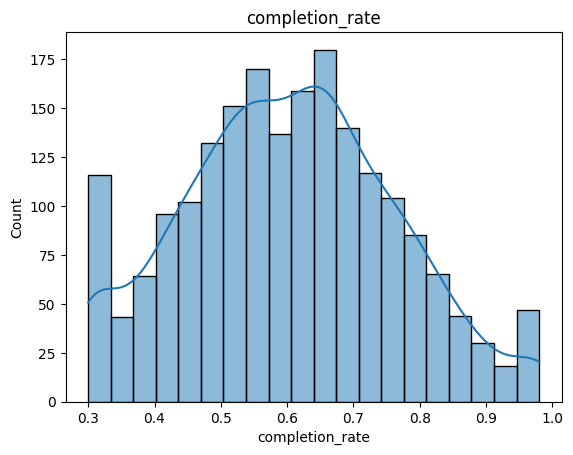

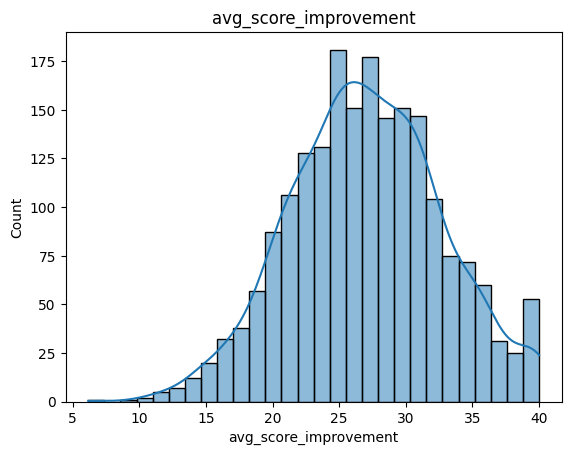

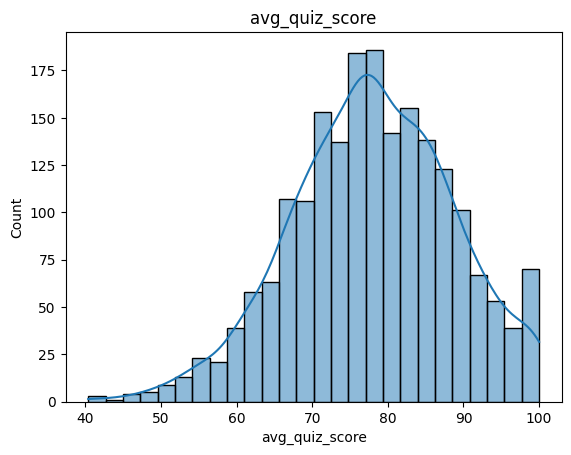

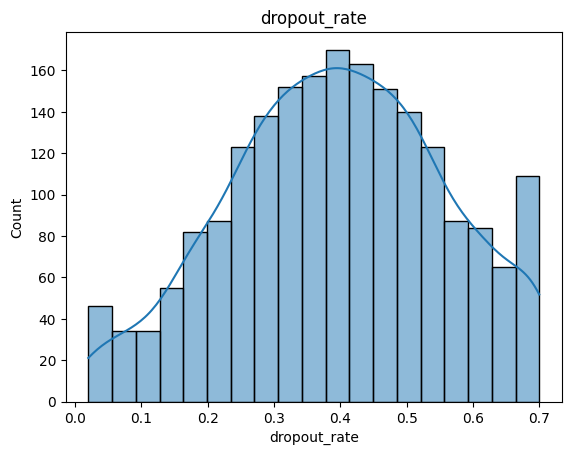

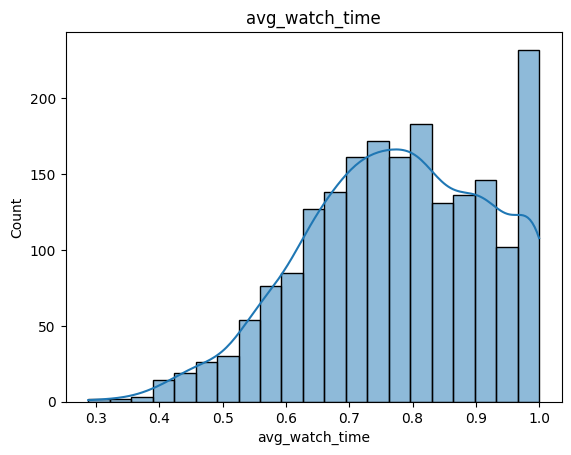

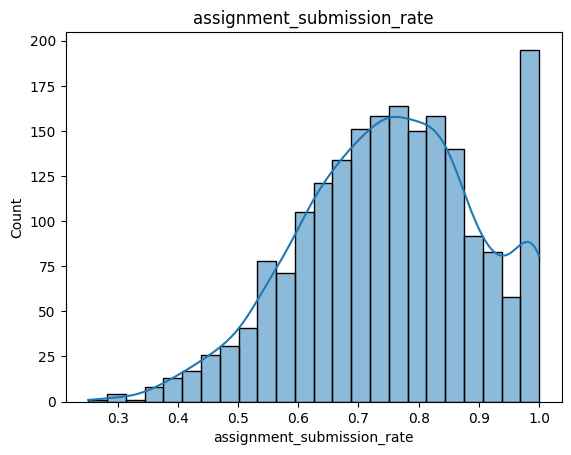

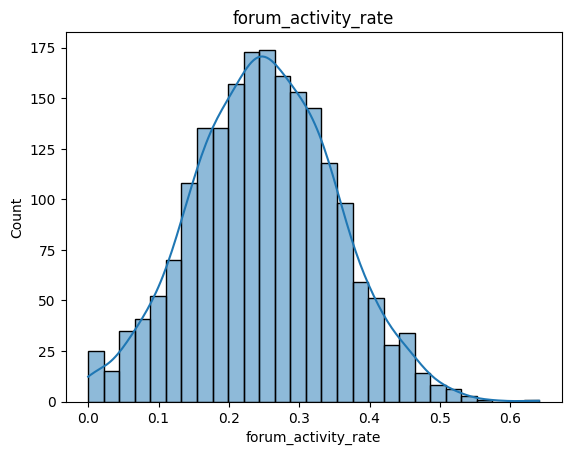

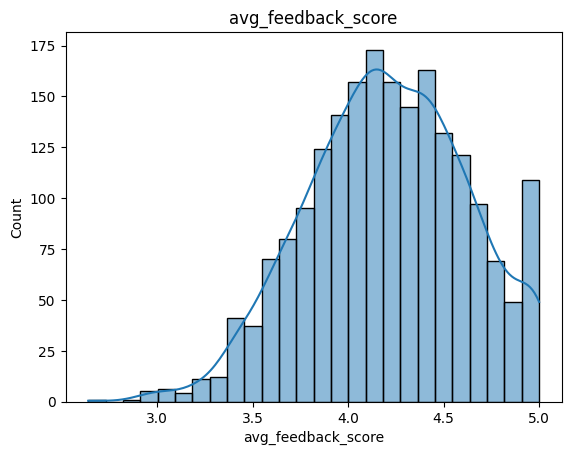

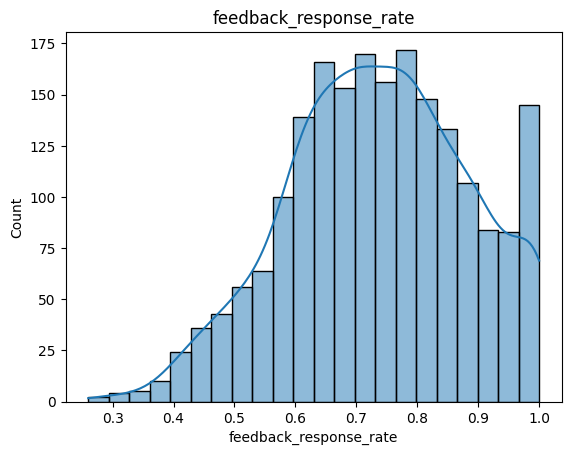

In [7]:
cols = [
'completion_rate',
'avg_score_improvement',
'avg_quiz_score',
'dropout_rate',
'avg_watch_time',
'assignment_submission_rate',
'forum_activity_rate',
'avg_feedback_score',
'feedback_response_rate'
]

for col in cols:
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

***---Most features are fairly normally distributed, indicating consistent performance across batches.\
---Engagement metrics are skewed towards higher values, while dropout rate shows moderate spread.***



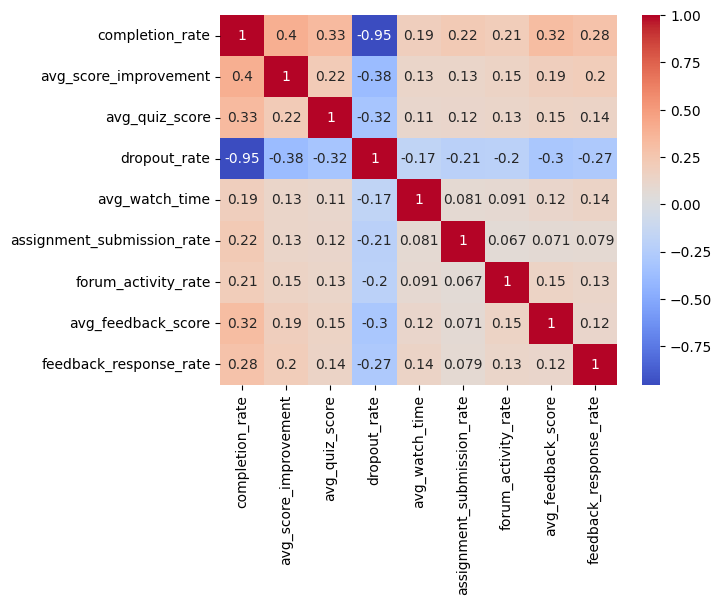

In [8]:
corr=df[cols].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

***---Completion Rate has a almost perfect negative correlation with dropout rate (-0.95) shows students who complete more coursework are much less likely to drop out.\
---Students with higher dropout rates show lower quiz scores (-0.32) and less score improvement (-0.38), indicating staying engaged directly affects learning outcomes.***

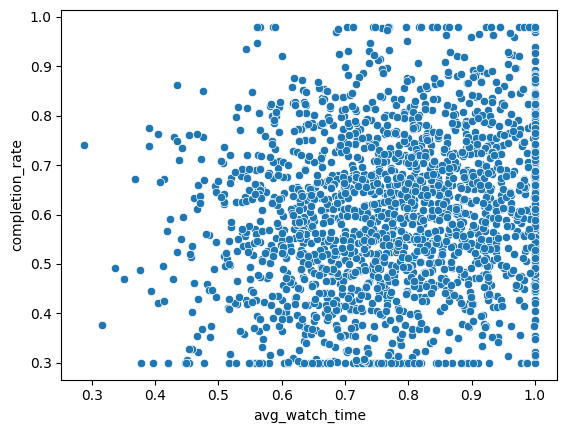

In [9]:
sns.scatterplot(data=df,x='avg_watch_time',y='completion_rate')
plt.show()

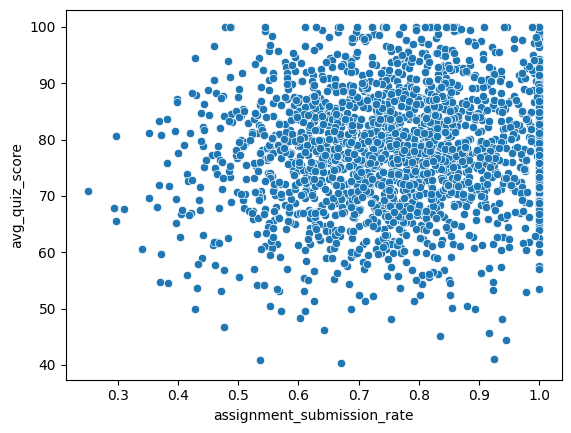

In [10]:
sns.scatterplot(data=df,x='assignment_submission_rate',y='avg_quiz_score')
plt.show()

***---Avg watch time shows positive relationship with completion rate, indicating higher engagement slightly improves completion.
---Students submitting more assignments (0.8-1.0) consistently score higher (80-100) on quizzes.***

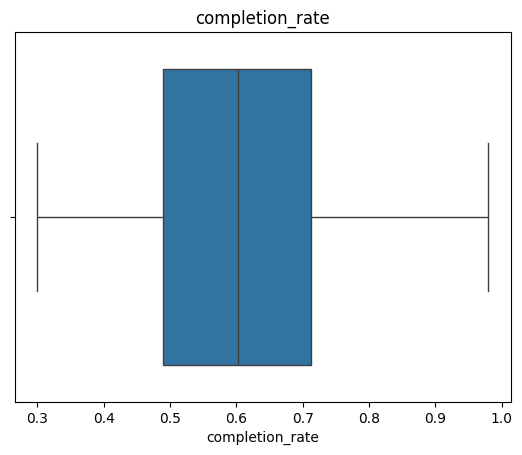

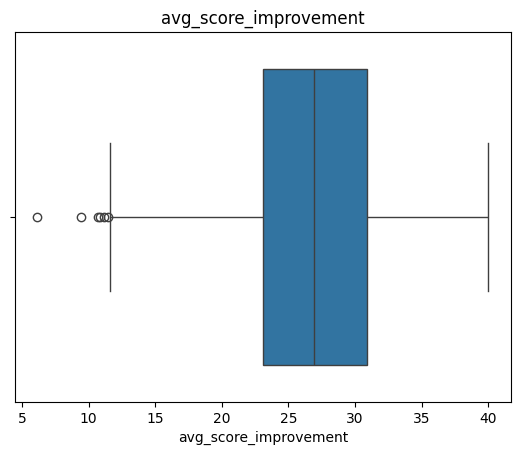

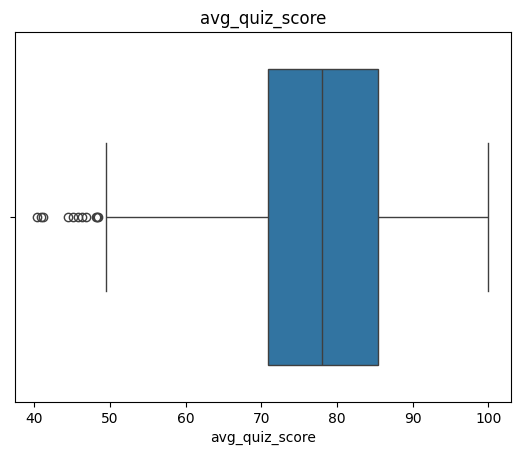

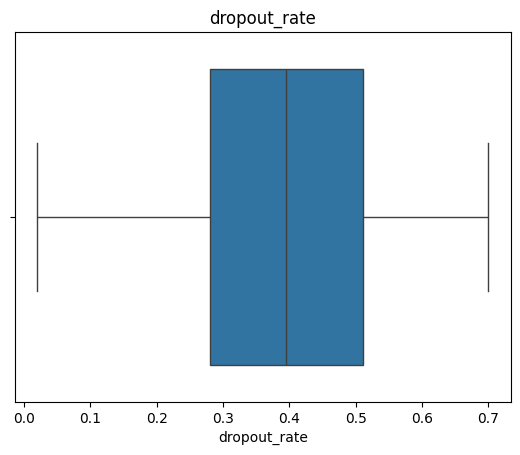

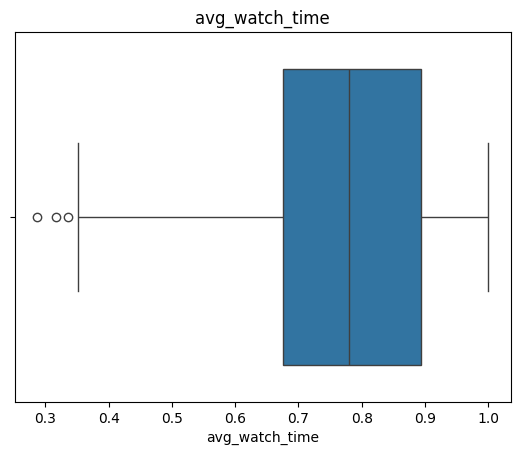

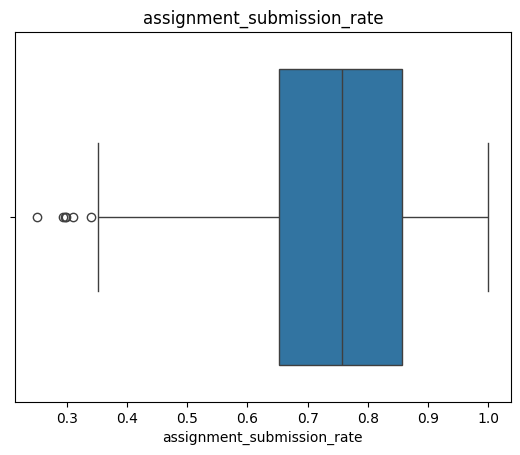

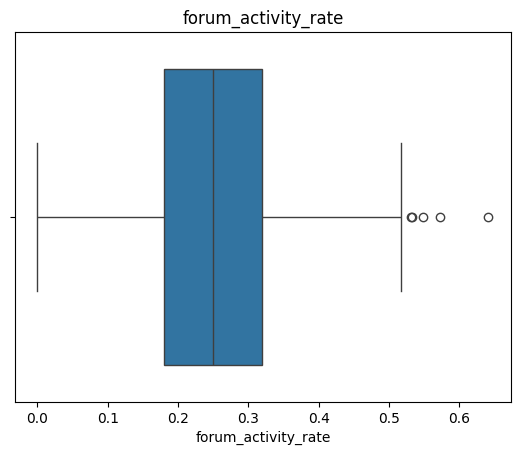

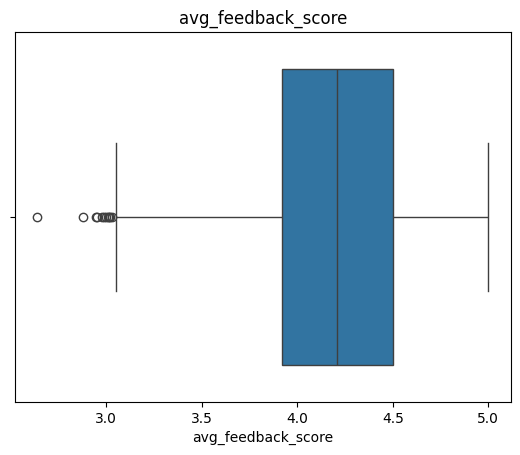

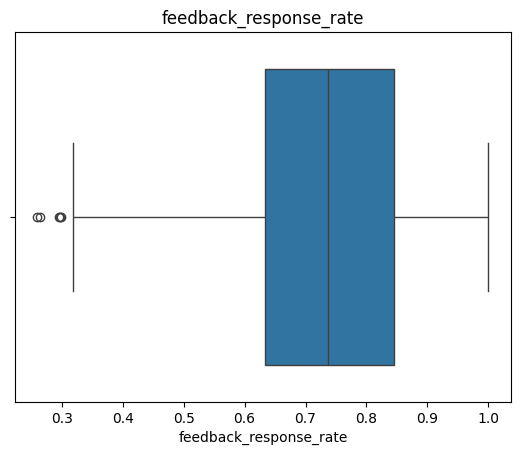

In [11]:
for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

***---score improvement, quiz score, and feedback score show outliers on the lower side, indicating a few low-performing batches.\
---watch time, assignment rate are concentrated at higher values, showing strong student participation.***

# **Define Instructor Effectiveness**

Instructor effectiveness is defined using student engagement, learning outcomes, and feedback metrics.

  Positive indicators:
- Completion rate
- Score improvement
- Quiz score
- Engagement metrics
- Feedback  

Negative indicator:
- Dropout rate


In [25]:

features = [
'completion_rate',
'avg_score_improvement',
'avg_quiz_score',
'dropout_rate',
'avg_watch_time',
'assignment_submission_rate',
'forum_activity_rate',
'avg_feedback_score',
'feedback_response_rate'
]

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features]) # Normalizing the feature

In [26]:
#Combining the feature into a single score

df["effectiveness_score"] = (
df["completion_rate"] +
df["avg_score_improvement"] +
df["avg_quiz_score"] +
df["avg_watch_time"] +
df["assignment_submission_rate"] +
df["forum_activity_rate"] +
df["avg_feedback_score"] +
df["feedback_response_rate"] -
df["dropout_rate"]
)

*---Positive indicators increase effectiveness.
Dropout reduces effectiveness.*

In [27]:
df["effectiveness_tier"] = pd.qcut(
df["effectiveness_score"],
q=3,
labels=["Low","Medium","High"]
)

*---The q=3 parameter divides instructors into three equal-sized groups (33.3% each), ensuring balanced representation across tiers.*

*---This method prevents skewed distributions where most instructors fall into one category, ensuring meaningful differentiation.*

In [28]:
instructor_df = df.groupby('instructor_id')[features + ['effectiveness_score']].mean().reset_index() # I used mean because It treats all batches equally

In [34]:
batch_counts = df.groupby("instructor_id").size()  # how many batches each instructor taught.

In [33]:
instructor_df["effectiveness_tier"] = pd.qcut(
instructor_df["effectiveness_score"],
q=3,
labels=["Low","Medium","High"]
)

In [31]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,effectiveness_tier
0,B_1861,I_044,C_01,0.000000,0.238373,0.556249,0.922681,0.683637,0.720811,0.169103,0.477227,0.369235,2.291953,Low
1,B_0354,I_119,C_06,0.525324,0.493839,0.619419,0.595732,0.291198,0.998085,0.437599,1.000000,0.640690,4.410422,Medium
2,B_1334,I_050,C_03,0.000000,0.293382,0.657185,1.000000,0.968987,0.742683,0.322898,0.371797,0.569542,2.926474,Low
3,B_0906,I_024,C_21,0.499274,0.534901,0.988179,0.462731,0.784601,0.391839,0.477913,0.664240,1.000000,4.878216,High
4,B_1290,I_001,C_08,0.334267,0.736459,0.989825,0.736911,0.884150,0.820915,0.393519,0.756886,0.590184,4.769295,High


*---Student-level data is aggregated by instructor using .groupby('instructor_id').mean() to calculate average metrics per instructor across all their students.*\
*---Quantile-based binning ensures equal distribution across tiers (33.3% each)*

# **Machine Learning Model**

In [35]:
X = instructor_df.drop(["instructor_id","effectiveness_tier","effectiveness_score"],axis=1)
y = instructor_df["effectiveness_tier"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
model = RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [41]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 6  0  1]
 [ 0  5  0]
 [ 0  1 11]]
              precision    recall  f1-score   support

        High       1.00      0.86      0.92         7
         Low       0.83      1.00      0.91         5
      Medium       0.92      0.92      0.92        12

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



In [43]:
# Class imbalance check :- If one class has much more data than others, the model may become biased.
y.value_counts()

,count
effectiveness_tier,
Low,40
Medium,40
High,40


# **Feature Importance**

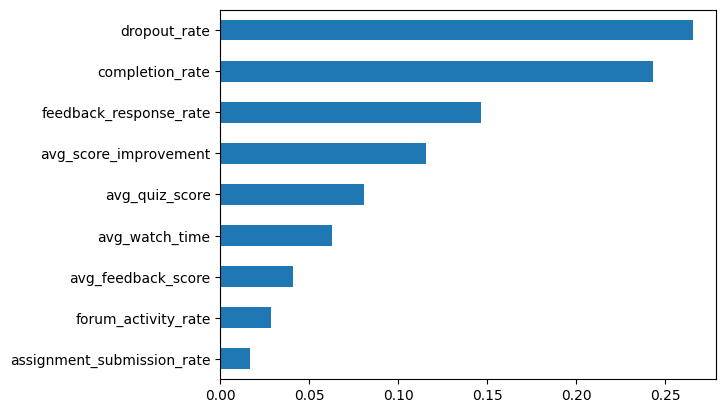

In [22]:
importance = pd.Series(model.feature_importances_,index=X.columns)

importance.sort_values().plot(kind='barh')
plt.show()

*---Dropout rate and completion rate are the most imprtant features, indicating teachers effectiveness is primarily based on keeping student engaged and preventing them from leaving the course.*

*---Engagement and performance metrics like score improvement and feedback response also contribute but have lower impact.*

*---Instructors are more effective when students stay engaged, complete the course, improve their scores, and actively participate in quiz and forum acticity.*

*---These insights can help identify top instructors, improve low-performing ones, and personalize course strategies to increase student engagement and success.*

# **Analysis Questions**

# **1-Which features most influenced instructor effectiveness, and why?**

**Dropout rate and Completion rate influenced instructor effectiveness the most because they directly measure student retention, which is the clearest signal of instructor impact.**

# **2-Which variables could be misleading or confounded?**

**Forum activity, watch time, and feedback scores can be misleading as they are influenced by student behavior and bias.**

# **3-How could this model fail in real-world usage?**

**The model may fail due to limited data, external factors like course difficulty, and changing student behavior.**

# **4-What additional data would you want to improve this analysis?**

**Course difficulty, student background, and instructor experience would improve the analysis.**

# **5-Should this model be used for instructor performance evaluation? Why or why not?**

**Use only as a supplementary tool, not primary evaluation—it lacks context, can be gamed, and may unfairly penalize difficult courses or certain student groups.**